In [1]:
import os
import pathlib
from copy import deepcopy
from tqdm.notebook import tqdm

from matplotlib import cm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression
from scipy.ndimage import gaussian_filter

from navigoquest.paths import PathDataset, Path
from navigoquest.environments import CohortEnvironment, EnvironmentStore
from navigoquest.utils.config import standard_dirs, LEVELS, METADATA_COLS, AGE_RANGE, ODMAT_WEIGHT_SCALE, ODMAT_WINDOW_SIZE
from navigoquest import format_metric_task_data
from navigoquest.utils.pipelines import load_environment, load_paths_normative, pipeline_compute_features

SAMPLE_RATE = 2.0  # Path datapoint sample rate, per second (baked into this dataset's collection method)
SMOOTH_RATE = 3  # Gaussian smoothing rate in our paper

In [2]:
# Simple logistic regression classifier
def fit_logistic_and_score(x_arr, y_arr):
    X = x_arr.reshape(-1, 1)
    Y = y_arr
    clf = LogisticRegression()
    clf.fit(X, Y)
    sco_arr = clf.predict_proba(X)[:, 1]
    return clf, sco_arr

def sigmoid_ftn(x):
    return 1/(1+np.exp(-x))

In [3]:
# Settings common over levels
early_stop = np.inf
task_list = ['voc', 'path_length', 'average_curvature', 'boundary_affinity',
             'frobenius_deviation', 'supremum_deviation', 'conformity', 'vector_conformity']

# Directories
dirs = standard_dirs()
paths_dir = dirs['paths']
output_dir = dirs['output']
cohort_env_dir = dirs['env_cohort']
dirs['online'] = dirs['cwd'] / '../data/online'
online_dir = dirs['online']

# Output directories for this notebook; created when they don't exist
online_dataframe_dir = online_dir / "online_metric_dataframes"
output_roc_dir = online_dir / "online_metric_roc_data"
for _d in (online_dir, online_dataframe_dir, output_roc_dir):
    _d.mkdir(parents=True, exist_ok=True)

# Load environment
env_store = load_environment(dirs)

# Load the full metrics dataframe
output_filenames = {lvl: f"metrics_level{lvl:02}_gb_2480.csv" for lvl in np.arange(1, 99)}
full_metrics = {lvl: pd.read_csv(output_dir / output_filenames[lvl]) for lvl in LEVELS}

# Select rows with age in the range 50 to 80
full_metrics_5080 = {}
for lvl in LEVELS:
    full_metrics_5080[lvl] = full_metrics[lvl][(full_metrics[lvl]['age'] >= 50) & (full_metrics[lvl]['age'] <= 80)]
    full_metrics_5080[lvl] = full_metrics_5080[lvl].reset_index(drop=True)

# Cohort sizes
cohort_sizes = {}
for lvl in LEVELS:
    agemask1 = full_metrics[lvl]['age'].to_numpy() >= 50
    agemask2 = full_metrics[lvl]['age'].to_numpy() <= 80
    agemask = np.logical_and(agemask1, agemask2)
    cohort_sizes[lvl] = int(np.sum(agemask))

# Plot names for metrics
metric_plotname_dict = {'velocity': 'Vel',
                        'duration': 'Dur',
                        'path_length': 'Len',
                        'average_curvature': 'Curv',
                        'boundary_affinity': 'Bdry',
                        'frobenius_deviation': 'FDev',
                        'supremum_deviation': 'SDev',
                        'conformity': 'MCon',
                        'vector_conformity': 'VCon'}

Loading environment data...
done. 



# 0. Sub-indices
Exclude half the entries to compute the OD matrices for.
Use the non-excluded half to compute path metrics

In [4]:
# Load or generate random subset of indices
seed = 1234
prop_subset = 0.5
inds_dir = online_dir / 'inds_subset.npz'
if inds_dir.exists():
    loaded_file = np.load(inds_dir, allow_pickle=True)
    inds_sub_all = dict(loaded_file)['arr_0'].item()
else:
    rng = np.random.default_rng(seed)

    # Random indices with seed
    inds_sub_all = {}
    for lvl in LEVELS:
        n = cohort_sizes[lvl]
        inds_sub = np.sort(rng.choice(n, int(n * prop_subset), replace=False))
        inds_sub_all[lvl] = inds_sub

    # Save
    np.savez(inds_dir, inds_sub_all)

In [5]:
# Compute complementary masks and indices
mask_sub_all = {}
mask_sub2_all = {}
inds_sub2_all = {}
for lvl in LEVELS:
    n = cohort_sizes[lvl]
    n_sub = inds_sub_all[lvl].size
    inds_full = np.arange(n)
    inds_sub = inds_sub_all[lvl]
    mask = np.zeros(n)
    j = 0
    for i in np.arange(n):
        if j == n_sub:
            break
        if inds_full[i] == inds_sub[j]:
            j += 1
            mask[i] = 1
    assert np.sum(mask) == n_sub
    assert np.all(np.nonzero(mask)[0] == inds_sub)
    mask = mask.astype(bool)
    mask_sub_all[lvl] = mask
    mask_sub2_all[lvl] = np.logical_not(mask)
    inds_sub2_all[lvl] = np.nonzero(np.logical_not(mask))[0]

In [6]:
# Check that masks and indices are computed correctly
checker = True
for lvl in LEVELS:
    comparator1 = inds_sub_all[lvl] == np.nonzero(mask_sub_all[lvl])[0]
    comparator2 = inds_sub2_all[lvl] == np.nonzero(mask_sub2_all[lvl])[0]
    comparator3 = mask_sub_all[lvl] == np.logical_not(mask_sub2_all[lvl])
    checker = checker and np.all(comparator1) and np.all(comparator2) and np.all(comparator3)
if checker:
    print(f'Correctly computed (masks and indices)')
else:
    print(f'Warning: Incorrectly computed (masks and indices)')

Correctly computed (masks and indices)


In [7]:
# Load path datasets (with metadata)
datasets_all = {}
for lvl in tqdm(LEVELS):
    print(f"Loading Level {lvl}...")
    dataset = load_paths_normative(lvl, dirs, {'min': 50, 'max': 80}, 
                                   return_dataset_object=True)
    datasets_all[lvl] = dataset

  0%|          | 0/5 [00:00<?, ?it/s]

Loading Level 1...
Loading path data...
corrupted data for entry: 68826
corrupted data for entry: 117532
dropping 0 unmatched path(s)
done. 

Loading Level 2...
Loading path data...
corrupted data for entry: 44618
corrupted data for entry: 68024
dropping 0 unmatched path(s)
done. 

Loading Level 6...
Loading path data...
corrupted data for entry: 49304
corrupted data for entry: 49432
dropping 0 unmatched path(s)
done. 

Loading Level 8...
Loading path data...
corrupted data for entry: 33652
corrupted data for entry: 79820
dropping 0 unmatched path(s)
done. 

Loading Level 11...
Loading path data...
corrupted data for entry: 27905
corrupted data for entry: 95579
dropping 0 unmatched path(s)
done. 



# 2. OD Matrix for a subset

In [8]:
# Create PathDataset object of non-excluded subset (sub), per level
dataset_sub_all = {}
for lvl in LEVELS:
    paths_now = [datasets_all[lvl].paths[ind] for ind in inds_sub_all[lvl]]
    metadata_now = datasets_all[lvl].user_metadata.iloc[inds_sub_all[lvl]]
    metadata_now = metadata_now.reset_index(drop=True)
    dataset_sub = PathDataset(paths_now, metadata_now)
    dataset_sub_all[lvl] = dataset_sub

# Create PathDataset object of excluded subset (sub2), per level
dataset_sub2_all = {}
for lvl in LEVELS:
    paths_now = [datasets_all[lvl].paths[ind] for ind in inds_sub2_all[lvl]]
    metadata_now = datasets_all[lvl].user_metadata.iloc[inds_sub2_all[lvl]]
    metadata_now = metadata_now.reset_index(drop=True)
    dataset_sub2 = PathDataset(paths_now, metadata_now)
    dataset_sub2_all[lvl] = dataset_sub2

# Compute OD matrices.
# These are generated by this notebook, so recompute whenever any level is absent.
compute_od_matrices_for_half = not all(
    (online_dir / f"level{lvl:02}_cohort_half.pkl").exists() for lvl in LEVELS
)
if compute_od_matrices_for_half:
    for lvl in LEVELS:
        print(f'Working on level {lvl}...')
        dataset_now = dataset_sub2_all[lvl]
        env = CohortEnvironment(level=lvl)
        env.set_od_matrices(dataset_now, *METADATA_COLS)
        env.transform_od_matrices_to_windowed(half_window=ODMAT_WINDOW_SIZE, scale=ODMAT_WEIGHT_SCALE,
                                            ignore_spill=True)
        env.set_mobility_fields()
        env.to_pickle(online_dir / f"level{lvl:02}_cohort_half.pkl")

# Load environment data
env_half_store = EnvironmentStore(online_dir, dirs["env_boundary"], LEVELS)

Working on level 1...
Working on level 2...
Working on level 6...
Working on level 8...
Working on level 11...


# 3. Distributions

In [9]:
# Path durations
path_durations = {lvl: [] for lvl in LEVELS}
for lvl in LEVELS:
    for item in dataset_sub_all[lvl].paths:
        item_dur = item.metadata['duration']
        path_durations[lvl].append(item_dur)
    path_durations[lvl] = np.array(path_durations[lvl])

# Path lengths
path_lengths = {lvl: [] for lvl in LEVELS}
for lvl in LEVELS:
    for item in dataset_sub_all[lvl].paths:
        item_path = item.xy
        item_len = np.linalg.norm(item_path[1:] - item_path[:-1], axis=1).sum()
        path_lengths[lvl].append(item_len)
    path_lengths[lvl] = np.array(path_lengths[lvl])

# Sorted duration and lengths
path_durations_sorted = {lvl: np.sort(path_durations[lvl]) for lvl in LEVELS}
path_lengths_sorted = {lvl: np.sort(path_lengths[lvl]) for lvl in LEVELS}

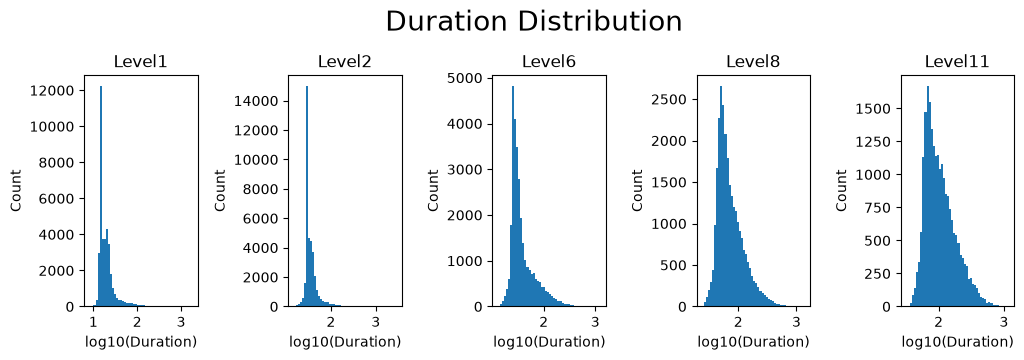

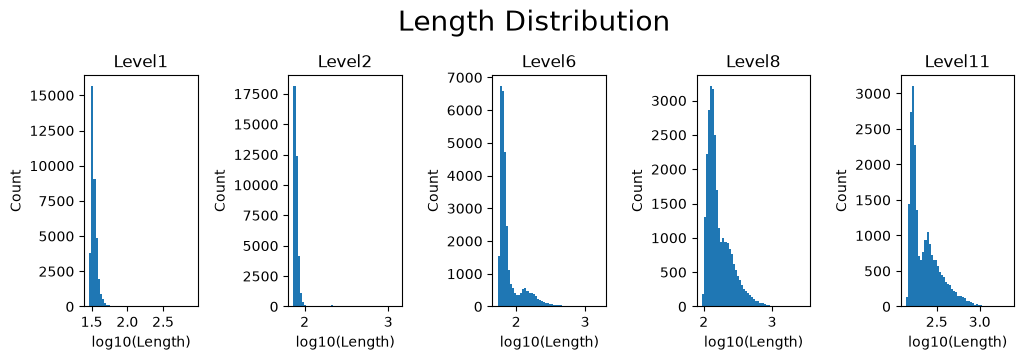

In [10]:
# Plot: Duration distribution
fig, ax = plt.subplots(ncols=5, nrows=1)
fig.set_size_inches(12, 3)
fig.subplots_adjust(wspace=0.8)
plt.suptitle(f'Duration Distribution', y=1.1, fontsize=20)
for i, lvl in enumerate(LEVELS):
    _ = ax[i].hist(np.log(path_durations[lvl])/np.log(10), bins=50)
    ax[i].set_xlabel(f'log10(Duration)')
    ax[i].set_ylabel(f'Count')
    ax[i].set_title(f'Level{lvl}')
plt.show()

# Plot: Length distribution
fig, ax = plt.subplots(ncols=5, nrows=1)
fig.set_size_inches(12, 3)
fig.subplots_adjust(wspace=0.8)
plt.suptitle(f'Length Distribution', y=1.1, fontsize=20)
for i, lvl in enumerate(LEVELS):
    _ = ax[i].hist(np.log(path_lengths[lvl])/np.log(10), bins=50)
    ax[i].set_xlabel(f'log10(Length)')
    ax[i].set_ylabel(f'Count')
    ax[i].set_title(f'Level{lvl}')
plt.show()

In [11]:
# Compute quantile values
prop_quantiles = np.linspace(0, 1, 6)

# Duration quantiles
path_duration_quantiles = {}
for lvl in LEVELS:
    path_duration_quantiles[lvl] = [np.quantile(path_durations[lvl], prop) for prop in prop_quantiles]
    path_duration_quantiles[lvl] = np.array(path_duration_quantiles[lvl])

# Length quantiles
path_length_quantiles = {}
for lvl in LEVELS:
    path_length_quantiles[lvl] = [np.quantile(path_lengths[lvl], prop) for prop in prop_quantiles]
    path_length_quantiles[lvl] = np.array(path_length_quantiles[lvl])

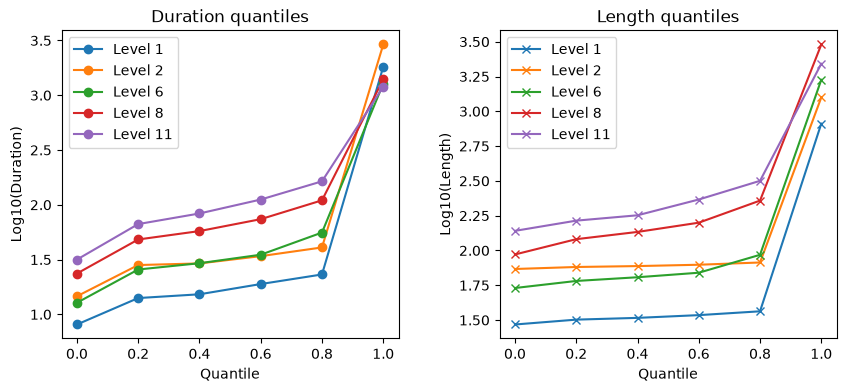

In [12]:
fig, ax = plt.subplots(ncols=2, nrows=1)
fig.set_size_inches(10, 4)
fig.subplots_adjust(wspace=0.3)

for lvl in LEVELS:
    ax[0].plot(prop_quantiles, np.log(path_duration_quantiles[lvl])/np.log(10), marker='o', label=f'Level {lvl}')
    ax[1].plot(prop_quantiles, np.log(path_length_quantiles[lvl])/np.log(10), marker='x', label=f'Level {lvl}')
ax[0].legend()
ax[0].set_title('Duration quantiles')
ax[0].set_ylabel('Log10(Duration)')
ax[0].set_xlabel(f'Quantile')

ax[1].legend()
ax[1].set_title('Length quantiles')
ax[1].set_ylabel('Log10(Length)')
ax[1].set_xlabel(f'Quantile')

plt.show()

# 4. Metric for snipped paths

In [13]:
# Setting
snip_methods = ['length_quantile']
metrics_for_online = ['velocity', 'duration'] + task_list[1:]
n_snip_all = {item: {} for item in snip_methods}

In [14]:
# Compute n_snips per snip method
for idx_quantile, quantile in enumerate(prop_quantiles):
    print(f'Working on quantile={round(quantile, 2)}...')
    for lvl in LEVELS:
        for method in snip_methods:
            if method == 'duration_percentage':
                # Is path_durations and paths_now aligned? -> Yes (Check above and below)
                snip_duration = quantile * path_durations[lvl]
                # paths_now = dataset_sub_all[lvl].paths
                n_snips = [int(item * SAMPLE_RATE) for item in snip_duration]
            elif method == 'length_percentage':
                snip_length_now_all = quantile * path_lengths[lvl] # List of numbers
                paths_now = dataset_sub_all[lvl].paths
                n_snips = []
                for item, item_snip_length in zip(paths_now, snip_length_now_all):
                    item_path = item.xy
                    item_len = np.linalg.norm(item_path[1:] - item_path[:-1], axis=1)
                    cumsum_len = np.cumsum(item_len)
                    n_points = np.searchsorted(cumsum_len, item_snip_length)
                    n_snips.append(n_points)
            elif method == 'duration_quantile':
                snip_duration = path_duration_quantiles[lvl][idx_quantile]
                paths_now = dataset_sub_all[lvl].paths
                n_snips = [int(snip_duration * SAMPLE_RATE) for _ in paths_now]
            elif method == 'length_quantile':
                snip_length = path_length_quantiles[lvl][idx_quantile] # Single number
                paths_now = dataset_sub_all[lvl].paths
                n_snips = []
                for item in paths_now:
                    item_path = item.xy
                    item_len = np.linalg.norm(item_path[1:] - item_path[:-1], axis=1)
                    cumsum_len = np.cumsum(item_len)
                    n_points = np.searchsorted(cumsum_len, snip_length)
                    n_snips.append(n_points)

            n_snips = np.array([int(item) for item in n_snips])
            n_snip_all[method][(lvl, quantile)] = n_snips

Working on quantile=0.0...
Working on quantile=0.2...
Working on quantile=0.4...
Working on quantile=0.6...
Working on quantile=0.8...
Working on quantile=1.0...


In [15]:
# Compute online metrics
online_dataframe_dir = online_dir / "online_metric_dataframes"

online_metrics = {method: {} for method in snip_methods}
for quantile in prop_quantiles: # for quantile in prop_quantiles:
    print(f'Working on quantile={round(float(quantile), 3)}...')
    for lvl in [6, 8, 11]: # for lvl in LEVELS:
        for method in snip_methods: # for method in snip_methods:
            # Try to load computed dataframe
            key_filename = (method, lvl, float(quantile))
            key_filename_display = (method, lvl, round(float(quantile), 3))
            filename = f"online_metrics_{key_filename}"
            if (online_dataframe_dir / filename).exists():
                output_df = pd.read_csv(online_dataframe_dir / filename, index_col=0)
                online_metrics[method][(lvl, quantile)] = output_df
                print(f'Loaded precomputed online metrics for {key_filename_display}')
                continue
            
            # Compute the dataframe, after not loading the dataframe
            paths_now = dataset_sub_all[lvl].paths
            paths_snipped = []
            n_snip_now = n_snip_all[method][(lvl, quantile)]

            # Snip the paths
            for item_path, item_snip in zip(paths_now, n_snip_now):
                # Snip
                item_xy_snipped = item_path.xy[:item_snip]
                path_snipped = Path(xy=item_xy_snipped, metadata=item_path.metadata)
                path_snipped.smooth_xy
                
                # Check smoothing worked correctly
                n_points = path_snipped.xy.shape[0]
                n_points_smoothed = path_snipped.smooth_xy.shape[0]
                assert n_points_smoothed+2 == 3*n_points

                # Append
                paths_snipped.append(path_snipped)
            
            # Compute metrics for snipped paths (online metrics)
            env_data = env_half_store.get(lvl) # OD matrices from the excluded half
            task_data = format_metric_task_data(task_list)
            pipeline_output = pipeline_compute_features(paths_snipped, env_data, task_data)
            output_df = pd.DataFrame.from_records(pipeline_output)

            # Compute duration, velocity separately
            # Take negative sign on vel, because high velocity corr. with good navigation
            output_df['duration'] = np.array(n_snip_now) / SAMPLE_RATE
            output_df['velocity'] = -output_df['path_length'] / output_df['duration']

            # Append
            online_metrics[method][(lvl, quantile)] = output_df

            # Save
            output_df = online_metrics[method][(lvl, quantile)]
            online_dataframe_dir = online_dir / "online_metric_dataframes"
            filename = f"online_metrics_{key_filename}"
            output_df.to_csv(online_dataframe_dir / filename)

Working on quantile=0.0...


  0%|          | 0/30488 [00:00<?, ?it/s]

  0%|          | 0/27416 [00:00<?, ?it/s]

  0%|          | 0/22556 [00:00<?, ?it/s]

Working on quantile=0.2...


...

  0%|          | 0/22556 [00:00<?, ?it/s]

Working on quantile=1.0...


  0%|          | 0/30488 [00:00<?, ?it/s]

  0%|          | 0/27416 [00:00<?, ?it/s]

  0%|          | 0/22556 [00:00<?, ?it/s]

In [16]:
# Sort the array of strings to compare with another array of strings
# Sanity check
checker1 = np.sort(full_metrics_5080[6]['user_id'].to_numpy())
checker2 = np.sort(datasets_all[6].user_metadata.user_id.to_numpy())
print(np.all(checker1 == checker2))

True


In [17]:
# Collect ROC data to export, so that a R script can be run.
# The script below plots the AUC values without confidence intervals.
# There is a separate notebook for plotting AUC values WITH confidence intervals.

method = 'length_quantile'
roc_data = [[{} for _ in prop_quantiles] for _ in [6, 8, 11]]
for idx_lvl, lvl in enumerate([6, 8, 11]):

    # Use user ID to match the rows of full_metrics_5080 and datasets_all
    argsort_metrics = np.argsort(full_metrics_5080[lvl]['user_id'].to_numpy())
    argsort_inv_metrics = np.argsort(argsort_metrics) # Applying twice inverts
    argsort_dataset = np.argsort(datasets_all[lvl].user_metadata.user_id.to_numpy())
    argsort_inv_dataset = np.argsort(argsort_dataset) # Applying twice inverts

    # Retrieve VOC
    vocs = full_metrics_5080[lvl]['voc'].to_numpy()
    # User ID to match entries
    vocs = vocs[argsort_metrics][argsort_inv_dataset][inds_sub_all[lvl]]

    # Compute AUC and Logistic regression
    for idx_quantile, quantile in enumerate(prop_quantiles):
        roc_data[idx_lvl][idx_quantile]['voc'] = vocs
        for item in metrics_for_online:
            metrics = online_metrics[method][(lvl, quantile)][item].to_numpy()
            clf, logsco_now = fit_logistic_and_score(metrics, vocs)
            roc_data[idx_lvl][idx_quantile][item] = logsco_now

# Save data
output_roc_dir = online_dir / "online_metric_roc_data"
os.makedirs(output_roc_dir, exist_ok=True)
for idx_lvl, lvl in enumerate([6, 8, 11]):
    for idx_quantile, quantile in enumerate(prop_quantiles):
        quantile_round = round(quantile, 3)
        filename = f"roc_data_lvl{lvl}_quantile{quantile_round}.csv"
        df = pd.DataFrame(roc_data[idx_lvl][idx_quantile])
        df.to_csv(os.path.join(output_roc_dir, filename), index=False)

In [18]:
method = 'length_quantile'
auc_all = {}
logsco_all = {}
for lvl in [6, 8, 11]:

    # Use user ID to match the rows of full_metrics_5080 and datasets_all
    argsort_metrics = np.argsort(full_metrics_5080[lvl]['user_id'].to_numpy())
    argsort_inv_metrics = np.argsort(argsort_metrics) # Applying twice inverts
    argsort_dataset = np.argsort(datasets_all[lvl].user_metadata.user_id.to_numpy())
    argsort_inv_dataset = np.argsort(argsort_dataset) # Applying twice inverts

    # Retrieve VOC
    vocs = full_metrics_5080[lvl]['voc'].to_numpy()
    # User ID to match entries
    vocs = vocs[argsort_metrics][argsort_inv_dataset][inds_sub_all[lvl]]

    # Compute AUC and Logistic regression
    auc_all_perlevel = {}
    logsco_all_perlevel = {}
    for item in metrics_for_online:
        auc_now_list = []
        logsco_now_list = []
        
        for quantile in prop_quantiles:
            metrics = online_metrics[method][(lvl, quantile)][item].to_numpy()

            # Logistic regression
            clf, logsco_now = fit_logistic_and_score(metrics, vocs)

            # AUC
            fpr, tpr, _ = roc_curve(vocs, logsco_now)
            auc_now = auc(fpr, tpr)
            
            auc_now_list.append(auc_now)
            logsco_now_list.append(logsco_now)
        auc_all_perlevel[item] = auc_now_list
        logsco_all_perlevel[item] = logsco_now_list
    auc_all[lvl] = auc_all_perlevel
    logsco_all[lvl] = logsco_all_perlevel

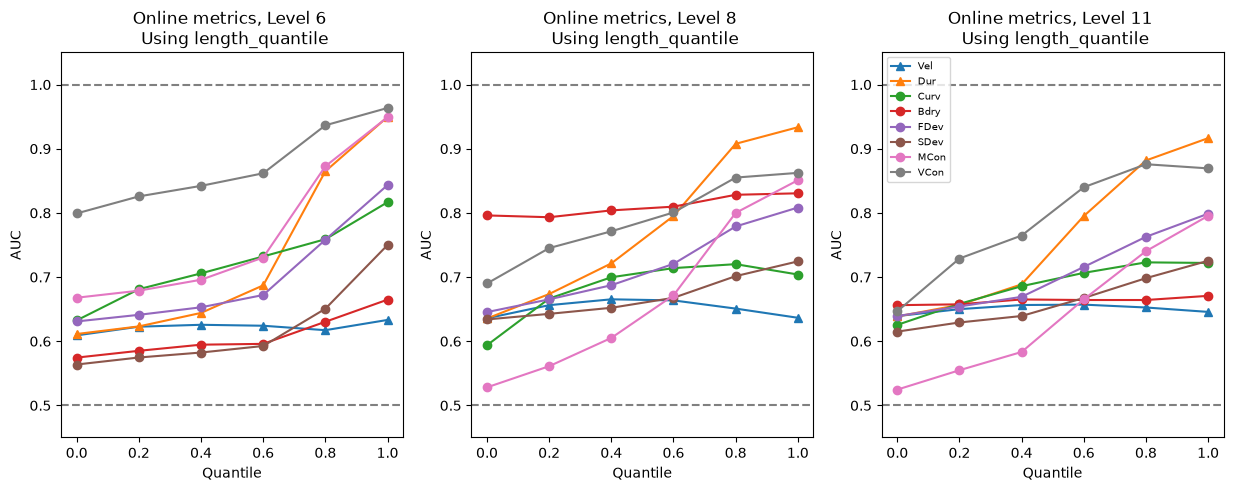

In [22]:
fig, ax = plt.subplots(ncols=3, nrows=1)

fig.set_size_inches(15, 5)
for i, lvl in enumerate([6, 8, 11]):
    ax[i].set_xlim([-0.05, 1.05])
    ax[i].set_ylim([0.45, 1.05])
    ax[i].plot([-0.05, 1.05], [0.5, 0.5], '--', c='gray')
    ax[i].plot([-0.05, 1.05], [1, 1], '--', c='gray')
    for item in metrics_for_online:
        if (item == 'path_length') and (method in {'length_quantile', 'length_percentage'}):
            continue
        elif (item == 'duration') and (method in {'duration_quantile', 'duration_percentage'}):
            continue
        plot_label = metric_plotname_dict[item]
        if plot_label in {'Vel', 'Dur', 'Len'}:
            plot_marker = '^'
        else:
            plot_marker = 'o'
        ax[i].plot(prop_quantiles, np.array(auc_all[lvl][item]), marker=plot_marker, label=plot_label)
    if i==2:
        ax[i].legend(prop={'size': 7})
    ax[i].set_xlabel(f'Quantile')
    ax[i].set_ylabel(f'AUC')
    ax[i].set_title(f'Online metrics, Level {lvl} \n Using {method}')
plt.show()

# 6. Individual paths

In [20]:
def linear_extend(values, res):
    # Extend values by resolution by linear interpolation (endpoint inclusive)
    n = values.size
    return np.interp(np.arange(1 + (n-1) * res)/res, np.arange(n), values)

def path_smooth(path, spline_res = 3):
    return np.vstack((gaussian_filter(linear_extend(path[:, 0], spline_res), spline_res * 1.67),
                          gaussian_filter(linear_extend(path[:, 1], spline_res), spline_res * 1.67))).T

def mobfield(odmat, width, length):
    assert odmat.shape[0] == odmat.shape[1]
    N = odmat.shape[0]
    
    helpvec_x = np.arange(N)%width
    helpvec_y = np.floor(np.arange(N)/width)
    
    mob_x = helpvec_x @ odmat.T - (np.ones(N) @ odmat.T) * helpvec_x
    mob_y = helpvec_y @ odmat.T - (np.ones(N) @ odmat.T) * helpvec_y
    return (mob_x, mob_y)

def plot_mob(odmats, mobs, map_dims, ax, key, fig_scale = 0.1, arrowlen_scale = 5, arrow_scale = 12, auto_limits = True, mob_tol=0.0):
    lvl = key[0]
    (map_width, map_length) = map_dims[lvl]
    # plt.figure().set_size_inches(map_width * fig_scale, map_length * fig_scale)
    ax.set_xticks([])
    ax.set_yticks([])
    if auto_limits:
        ax.set_xlim([0, map_width])
        ax.set_ylim([0, map_length])
    odmat_now = odmats[key[0]][key[1:]].mat

    assert odmat_now.shape[0] == odmat_now.shape[1]
    assert odmat_now.shape[0] == map_width * map_length
    N = map_width * map_length

    mobfield_now = mobs[key]
    mob_x = mobfield_now[0]
    mob_y = mobfield_now[1]
    mob_norm = mob_norms[key]
    mob_maxnorm = np.max(mob_norm)
    for i in range(N):
        pos_x = i % map_width
        pos_y = np.floor(i / map_width)
        if mob_norm[i] > mob_tol:
            # plt.arrow(pos_x, pos_y, 10 * mob_x[i], 10 * mob_y[i], head_width = 0.01, 
                      # color = cm.viridis(mob_norm[i] / mob_maxnorm))
            ax.arrow(pos_x, pos_y, arrowlen_scale * mob_x[i], arrowlen_scale * mob_y[i], 
                      width = 0.01 * arrow_scale, head_width = 0.05 * arrow_scale, 
                      color = cm.Oranges(sigmoid_ftn(10 * mob_norm[i] / mob_maxnorm)),
                      alpha = sigmoid_ftn(10 * mob_norm[i] / mob_maxnorm))

IDs match
IDs match
IDs match


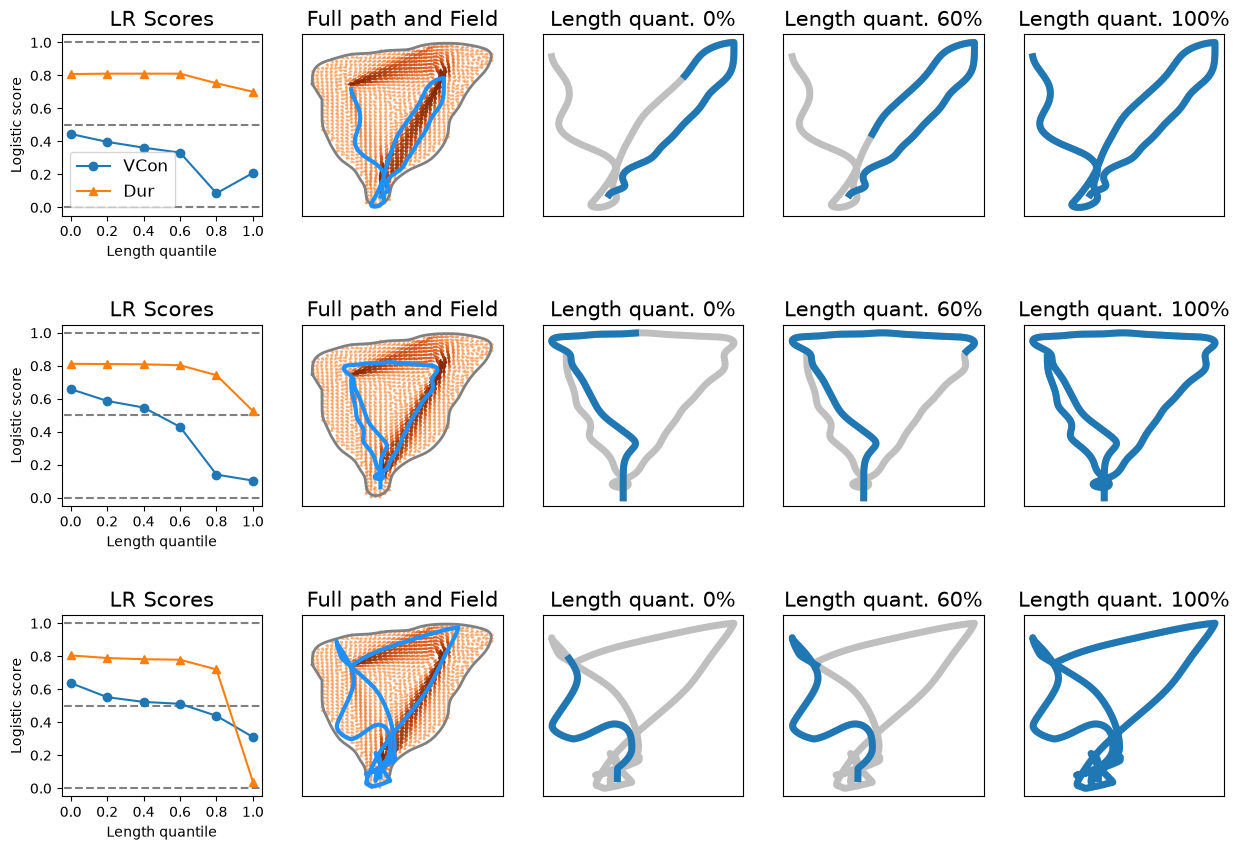

In [23]:
lvl = 6
inds_display = [103, 390, 203] 
method = 'length_quantile'

# For fixed level and method
n_snip_arr = [n_snip_all[method][(lvl, quantile)] for quantile in prop_quantiles]
n_snip_arr = np.array(n_snip_arr).T
paths_lvl = dataset_sub_all[lvl].paths
# bdy = np.load(dirs['env_boundary'] / f"level{lvl:02}_inner_bdry.npy") # Boundary

# Mobility field
odmats_all = {key: env_store.get(key)[0].od_matrices for key in [6, 8, 11]}
inner_bdy = {key: np.load(dirs['env_boundary'] / f"level{key:02}_inner_bdry.npy") for key in [6, 8, 11]}
inner_bdy = {key: path_smooth(inner_bdy[key]) for key in [6, 8, 11]}
map_dims = {key: (env_store.get(key)[0].grid_width, env_store.get(key)[0].grid_length) for key in [6, 8, 11]}
mobs = {}
mob_norms = {}
for ind_lvl, item_lvl in enumerate([6, 8, 11]):
    for gender in ['f', 'm']:
        for age in np.arange(50, 80 + 1):
            key = (item_lvl, age, gender)
            odmat_now = odmats_all[key[0]][key[1:]].mat
            mob = mobfield(odmat_now, map_dims[item_lvl][0], map_dims[item_lvl][1])
            mob_norm = np.sqrt(np.power(mob[0], 2) + np.power(mob[1], 2))
            mobs[key] = mob
            mob_norms[key] = mob_norm

# Plot
prop_quantiles_plot = [0.0, 0.6, 1.0]
fig, ax = plt.subplots(ncols = 2+len(prop_quantiles_plot), nrows=len(inds_display))
fig.set_size_inches(3*(2+len(prop_quantiles_plot)), 3.3*len(inds_display))
plt.subplots_adjust(wspace=0.2, hspace=0.6)
color1 = (0.6, 0.6, 0.6, 1) # Background
color2 = (0.9, 0.9, 0.9, 1) # Inner area

for i, idx in enumerate(inds_display):
    # Retrieve data to plot
    item_path = paths_lvl[idx].smooth_xy
    item_snip = n_snip_arr[idx]
    metrics_display1 = [logsco_all[lvl]['vector_conformity'][j][idx] for j in range(len(prop_quantiles))]
    metrics_display2 = [logsco_all[lvl]['duration'][j][idx] for j in range(len(prop_quantiles))]

    # ID check
    id1 = paths_lvl[idx].metadata['user_id'] 
    id2 = online_metrics[method][(lvl, 0.0)].loc[idx]['user_id']
    if id1 == id2:
        print(f'IDs match')
    else:
        print(f'IDs do not match')

    # Labels for plot
    if i == 0:
        label1 = 'VCon'
        label2 = 'Dur'
    else:
        label1 = None
        label2 = None
    
    # LR scores
    ax[i, 0].set_ylim([-0.05, 1.05])
    ax[i, 0].set_xlim([-0.05, 1.05])
    ax[i, 0].set_xticks(prop_quantiles)
    ax[i, 0].set_ylabel(f'Logistic score', fontsize=10)
    ax[i, 0].set_xlabel(f'Length quantile', fontsize=10)
    ax[i, 0].set_title(f'LR Scores', fontsize=15)
    ax[i, 0].plot([-0.1, 1.1], [0., 0.], linestyle='--', c='gray')
    ax[i, 0].plot([-0.1, 1.1], [0.5, 0.5], linestyle='--', c='gray')
    ax[i, 0].plot([-0.1, 1.1], [1.0, 1.0], linestyle='--', c='gray')
    ax[i, 0].plot(prop_quantiles, metrics_display1, marker='o', label=label1)
    ax[i, 0].plot(prop_quantiles, metrics_display2, marker='^', label=label2)

    # Mobility field plot
    key = (lvl, 60, 'f')
    odmat_now = odmats_all[key[0]][key[1:]].mat
    bdy_pts = inner_bdy[key[0]]
    bdy_pts_looped = np.vstack([bdy_pts, bdy_pts[0]])
    mob = mobfield(odmat_now, map_dims[lvl][0], map_dims[lvl][1])
    mob_norm = np.sqrt(np.power(mob[0], 2) + np.power(mob[1], 2))
    ax[i, 1].set_xticks([])
    ax[i, 1].set_yticks([])
    ax[i, 1].set_title(f'Full path and Field', fontsize=15)
    ax[i, 1].plot(bdy_pts_looped.T[0], bdy_pts_looped.T[1], linewidth = 2, color = 'gray')
    plot_mob(odmats_all, mobs, map_dims, ax[i, 1], key, fig_scale = 0.1, arrowlen_scale = 5, arrow_scale = 10, auto_limits=False)
    ax[i, 1].plot(item_path[:, 0], item_path[:, 1], linewidth=3, c='dodgerblue')

    # Partial paths
    prop_quantiles_list = [round(item, 5) for item in prop_quantiles]
    for j, quantile in enumerate(prop_quantiles_plot):
        jj = prop_quantiles_list.index(quantile)
        ax[i, j+2].plot(item_path[:, 0], item_path[:, 1], c='gray', alpha=0.5, linewidth=5)
        ax[i, j+2].plot(item_path[:3*item_snip[jj]][:, 0], item_path[:3*item_snip[jj]][:, 1], linewidth=5)
        ax[i, j+2].set_xticks([])
        ax[i, j+2].set_yticks([])
        ax[i, j+2].set_title(f'Length quant. {int(100*quantile)}%', fontsize=15)

ax[0, 0].legend(prop={'size': 12})
